[*********************100%***********************]  1 of 1 completed

=== MTM-SQZMOM Trading Strategy Backtest ===
Symbol: SPY
Period: 2023-08-17 to 2025-08-17
Initial Capital: $100,000
--------------------------------------------------



Trade Log:
BUY: 2025-01-23 Price: $606.13
SELL: 2025-01-27 Price: $595.81
BUY: 2025-01-30 Price: $601.45
SELL: 2025-02-05 Price: $600.63
BUY: 2025-02-14 Price: $606.08
SELL: 2025-02-21 Price: $596.38
BUY: 2025-04-30 Price: $552.91
SELL: 2025-08-01 Price: $621.72
BUY: 2025-08-04 Price: $631.17
SELL: 2025-08-05 Price: $627.97
... Total 38 trades
Final Portfolio Value: $111,100.69
Strategy Return: 11.10%
Buy & Hold Return: 51.41%
Excess Return: -40.30%
Sharpe Ratio: 0.50
Max Drawdown: -6.90%
Number of Trades: 38


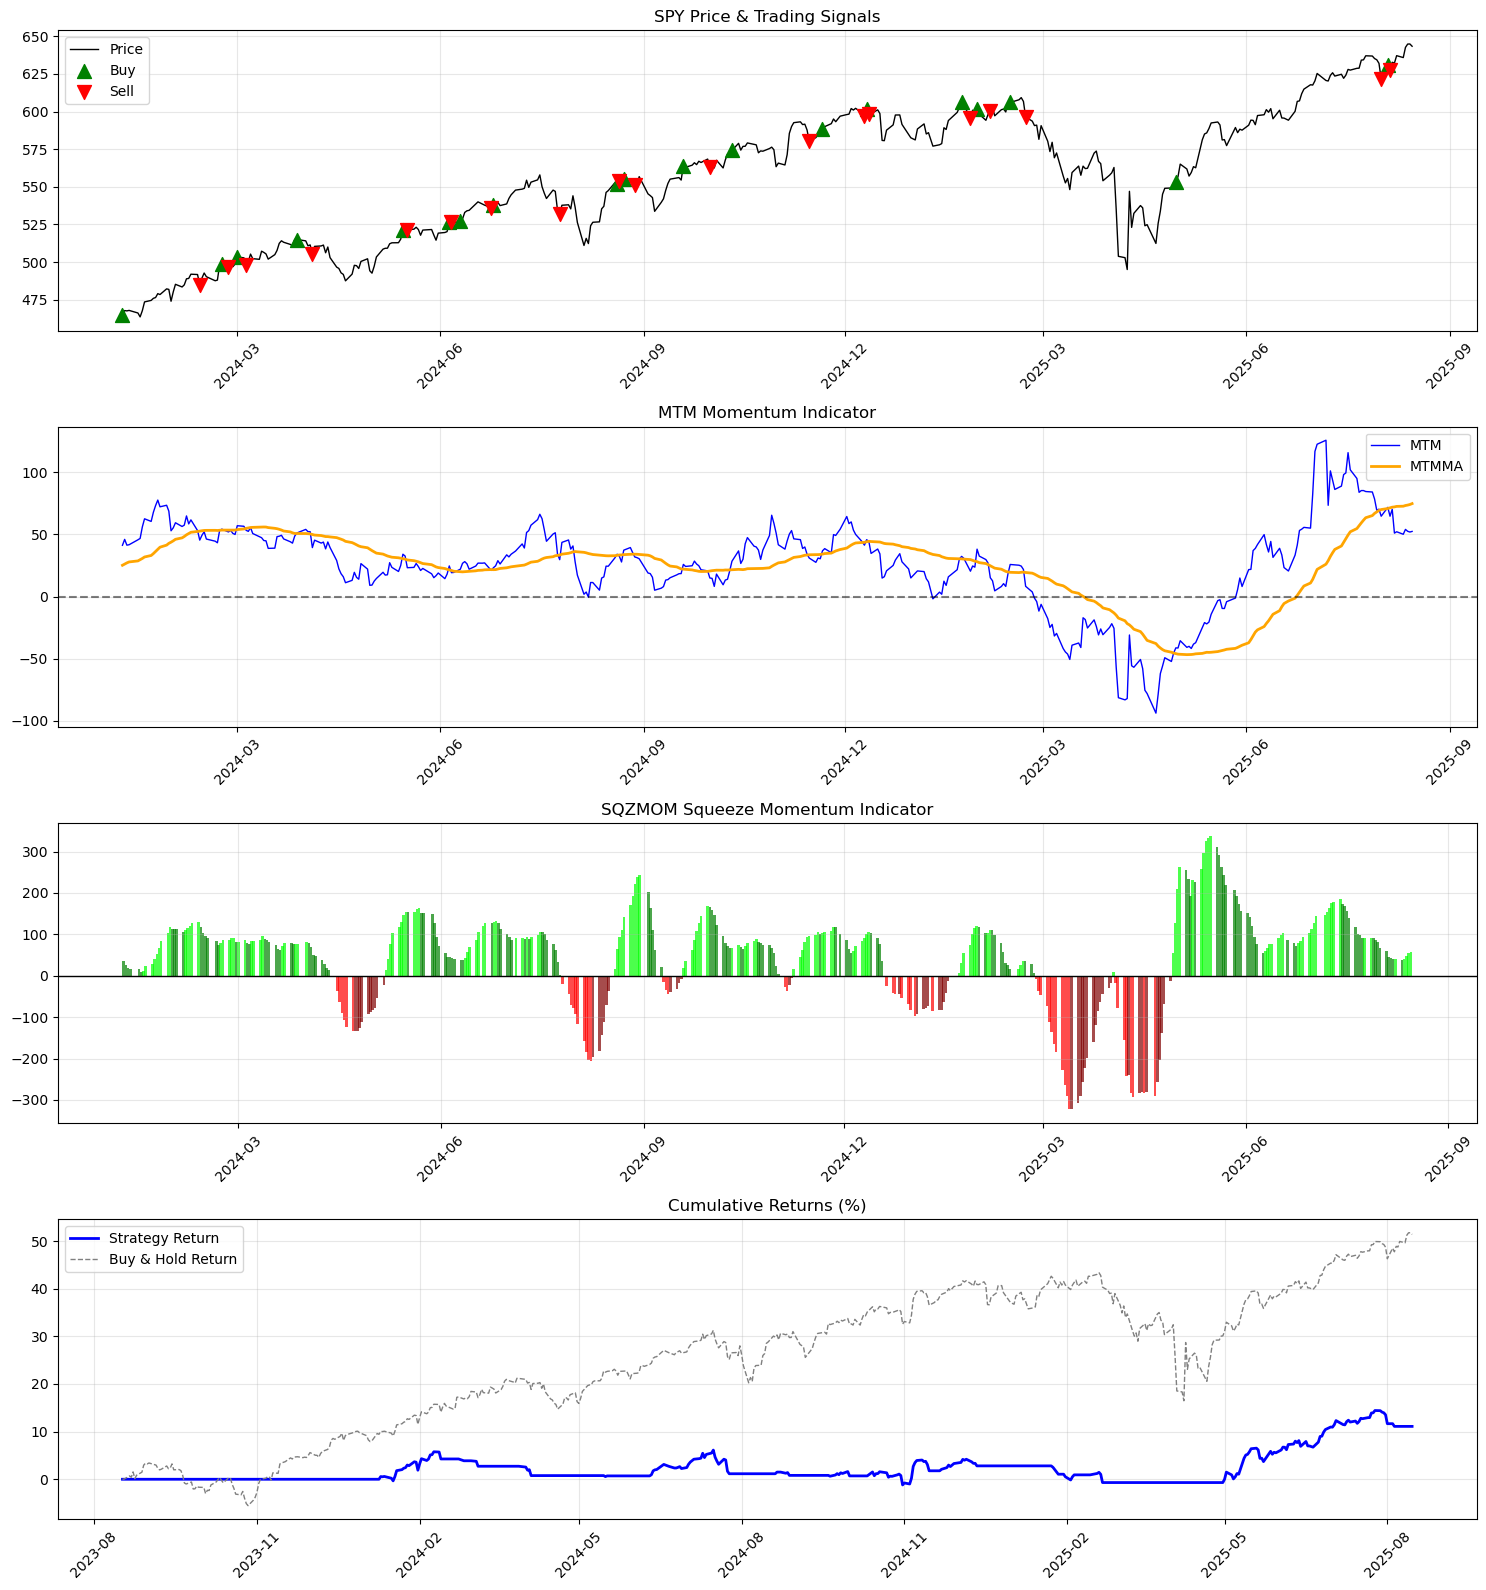

In [36]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class MTM_SQZMOM_Strategy:
    def __init__(self, initial_capital=100000):
        self.initial_capital = initial_capital
        
    def calculate_mtm(self, df, n=60, n1=40):
        """Calculate MTM indicator"""
        df['MTM'] = df['Close'] - df['Close'].shift(n)
        df['MTMMA'] = df['MTM'].rolling(window=n1).mean()
        
        # MTM color logic
        df['MTM_Color'] = 'black'
        df.loc[df['MTM'] < df['MTMMA'], 'MTM_Color'] = 'red'
        df.loc[df['MTM'] > df['MTMMA'], 'MTM_Color'] = 'green'
        
        return df
    
    def calculate_sqzmom(self, df, bb_length=20, bb_mult=2.0, kc_length=20, kc_mult=1.5, use_true_range=True):
        """Calculate SQZMOM indicator"""
        # Bollinger Bands
        bb_basis = df['Close'].rolling(window=bb_length).mean()
        bb_dev = kc_mult * df['Close'].rolling(window=bb_length).std()
        upper_bb = bb_basis + bb_dev
        lower_bb = bb_basis - bb_dev
        
        # Keltner Channel
        kc_ma = df['Close'].rolling(window=kc_length).mean()
        
        if use_true_range:
            high_low = df['High'] - df['Low']
            high_close_prev = np.abs(df['High'] - df['Close'].shift(1))
            low_close_prev = np.abs(df['Low'] - df['Close'].shift(1))
            true_range_df = pd.DataFrame({
                'hl': high_low,
                'hcp': high_close_prev,
                'lcp': low_close_prev
            }, index=df.index)
            true_range = true_range_df.max(axis=1)
        else:
            true_range = df['High'] - df['Low']
            
        range_ma = true_range.rolling(window=kc_length).mean()
        upper_kc = kc_ma + range_ma * kc_mult
        lower_kc = kc_ma - range_ma * kc_mult
        
        # Squeeze conditions
        sqz_on = (lower_bb > lower_kc) & (upper_bb < upper_kc)
        sqz_off = (lower_bb < lower_kc) & (upper_bb > upper_kc)
        no_sqz = ~sqz_on & ~sqz_off
        
        # Momentum value
        highest_high = df['High'].rolling(window=kc_length).max()
        lowest_low = df['Low'].rolling(window=kc_length).min()
        avg_hl = (highest_high + lowest_low) / 2
        avg_close = df['Close'].rolling(window=kc_length).mean()
        avg_val = (avg_hl + avg_close) / 2
        
        # Linear regression simplified
        momentum_vals = []
        
        for i in range(len(df)):
            if i < kc_length - 1:
                momentum_vals.append(np.nan)
                continue
            
            try:
                start_idx = max(0, i - kc_length + 1)
                end_idx = i + 1
                
                if pd.isna(avg_val.iloc[i]):
                    momentum_vals.append(np.nan)
                    continue
                    
                price_data = df['Close'].iloc[start_idx:end_idx].values
                base_value = avg_val.iloc[i]
                
                if len(price_data) < 2:
                    momentum_vals.append(np.nan)
                    continue
                
                y_data = price_data - base_value
                x_data = np.arange(len(y_data))
                
                if not np.any(np.isnan(y_data)) and len(y_data) > 1:
                    slope, _ = np.polyfit(x_data, y_data, 1)
                    momentum_vals.append(slope * 100)  # scaled for visibility
                else:
                    momentum_vals.append(np.nan)
                    
            except Exception as e:
                momentum_vals.append(np.nan)
        
        df['SQZMOM_Val'] = momentum_vals
        
        # SQZMOM color logic
        df['SQZMOM_Color'] = 'maroon'
        
        positive_mask = df['SQZMOM_Val'] > 0
        negative_mask = df['SQZMOM_Val'] < 0
        prev_val = df['SQZMOM_Val'].shift(1)
        
        df.loc[positive_mask & (df['SQZMOM_Val'] > prev_val), 'SQZMOM_Color'] = 'lime'
        df.loc[positive_mask & (df['SQZMOM_Val'] <= prev_val), 'SQZMOM_Color'] = 'green'
        df.loc[negative_mask & (df['SQZMOM_Val'] < prev_val), 'SQZMOM_Color'] = 'red'
        df.loc[negative_mask & (df['SQZMOM_Val'] >= prev_val), 'SQZMOM_Color'] = 'maroon'
        
        return df
    
    def backtest_strategy(self, symbol, start_date, end_date):
        """Run backtest strategy"""
        print(f"Downloading {symbol} data...")
        df = yf.download(symbol, start=start_date, end=end_date)
        
        if df.empty:
            raise ValueError(f"Could not retrieve {symbol} data")
        
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.droplevel(1)
        
        expected_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
        for col in expected_columns:
            if col not in df.columns:
                available_cols = [c for c in df.columns if col.lower() in c.lower()]
                if available_cols:
                    df[col] = df[available_cols[0]]
        
        df = self.calculate_mtm(df)
        df = self.calculate_sqzmom(df)
        
        # Trading signals
        buy_condition = (df['SQZMOM_Color'].isin(['lime', 'green'])) & (df['MTM_Color'] == 'green')
        sell_condition = df['MTM_Color'] == 'red'
        
        df['Signal'] = 0
        df['Position'] = 0
        df['Portfolio_Value'] = self.initial_capital
        
        position = 0
        shares = 0
        cash = self.initial_capital
        trades_log = []
        
        for i in range(1, len(df)):
            current_price = df['Close'].iloc[i]
            current_date = df.index[i]
            
            if buy_condition.iloc[i] and position == 0:
                shares = cash / current_price
                cash = 0
                position = 1
                df.loc[current_date, 'Signal'] = 1
                trades_log.append(f"BUY: {current_date.strftime('%Y-%m-%d')} Price: ${current_price:.2f}")
                
            elif sell_condition.iloc[i] and position == 1:
                cash = shares * current_price
                shares = 0
                position = 0
                df.loc[current_date, 'Signal'] = -1
                trades_log.append(f"SELL: {current_date.strftime('%Y-%m-%d')} Price: ${current_price:.2f}")
            
            portfolio_value = cash + (shares * current_price if shares > 0 else 0)
            df.loc[current_date, 'Portfolio_Value'] = portfolio_value
            df.loc[current_date, 'Position'] = position
        
        df['Returns'] = df['Portfolio_Value'].pct_change()
        df['Cumulative_Returns'] = (1 + df['Returns'].fillna(0)).cumprod() - 1
        
        df['Buy_Hold_Returns'] = df['Close'].pct_change()
        df['Buy_Hold_Cumulative'] = (1 + df['Buy_Hold_Returns'].fillna(0)).cumprod() - 1
        
        self.trades_log = trades_log
        
        return df
    
    def calculate_sharpe_ratio(self, df, risk_free_rate=0.02):
        """Calculate Sharpe Ratio"""
        returns = df['Returns'].dropna()
        excess_returns = returns - risk_free_rate / 252
        if excess_returns.std() == 0:
            return 0
        return np.sqrt(252) * excess_returns.mean() / excess_returns.std()
    
    def plot_results(self, df, symbol):
        """Plot results"""
        fig, axes = plt.subplots(4, 1, figsize=(15, 16))
        plot_df = df.dropna(subset=['MTM', 'MTMMA', 'SQZMOM_Val'])
        
        # Price with signals
        axes[0].plot(plot_df.index, plot_df['Close'], label='Price', color='black', linewidth=1)
        buy_signals = plot_df[plot_df['Signal'] == 1]
        sell_signals = plot_df[plot_df['Signal'] == -1]
        
        if len(buy_signals) > 0:
            axes[0].scatter(buy_signals.index, buy_signals['Close'], 
                           color='green', marker='^', s=100, label='Buy', zorder=5)
        if len(sell_signals) > 0:
            axes[0].scatter(sell_signals.index, sell_signals['Close'], 
                           color='red', marker='v', s=100, label='Sell', zorder=5)
        
        axes[0].set_title(f'{symbol} Price & Trading Signals')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # MTM
        axes[1].plot(plot_df.index, plot_df['MTM'], label='MTM', color='blue', linewidth=1)
        axes[1].plot(plot_df.index, plot_df['MTMMA'], label='MTMMA', color='orange', linewidth=2)
        axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[1].set_title('MTM Momentum Indicator')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # SQZMOM
        sqz_df = plot_df.dropna(subset=['SQZMOM_Val'])
        if len(sqz_df) > 0:
            colors = []
            for color in sqz_df['SQZMOM_Color']:
                if color == 'lime':
                    colors.append('lime')
                elif color == 'green':
                    colors.append('green')
                elif color == 'red':
                    colors.append('red')
                else:
                    colors.append('maroon')
            
            if len(sqz_df) > 1:
                time_diff = (sqz_df.index[-1] - sqz_df.index[0]).days
                bar_width = max(1, time_diff / len(sqz_df) * 0.8)
            else:
                bar_width = 1
                
            axes[2].bar(sqz_df.index, sqz_df['SQZMOM_Val'], 
                       color=colors, alpha=0.7, width=bar_width)
            
        axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axes[2].set_title('SQZMOM Squeeze Momentum Indicator')
        axes[2].grid(True, alpha=0.3)
        
        # Performance
        perf_df = df.dropna(subset=['Cumulative_Returns', 'Buy_Hold_Cumulative'])
        axes[3].plot(perf_df.index, perf_df['Cumulative_Returns'] * 100, 
                    label='Strategy Return', color='blue', linewidth=2)
        axes[3].plot(perf_df.index, perf_df['Buy_Hold_Cumulative'] * 100, 
                    label='Buy & Hold Return', color='gray', linewidth=1, linestyle='--')
        axes[3].set_title('Cumulative Returns (%)')
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)
        
        for ax in axes:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    def run_strategy(self, symbol, start_date, end_date, plot=True):
        """Run full strategy"""
        print("=== MTM-SQZMOM Trading Strategy Backtest ===")
        print(f"Symbol: {symbol}")
        print(f"Period: {start_date} to {end_date}")
        print(f"Initial Capital: ${self.initial_capital:,}")
        print("-" * 50)
        
        df = self.backtest_strategy(symbol, start_date, end_date)
        
        final_value = df['Portfolio_Value'].iloc[-1]
        total_return = (final_value - self.initial_capital) / self.initial_capital
        buy_hold_return = df['Buy_Hold_Cumulative'].iloc[-1]
        
        sharpe_ratio = self.calculate_sharpe_ratio(df)
        
        rolling_max = df['Portfolio_Value'].expanding().max()
        drawdown = (df['Portfolio_Value'] - rolling_max) / rolling_max
        max_drawdown = drawdown.min()
        
        trades = len(df[df['Signal'] != 0])
        
        if hasattr(self, 'trades_log') and len(self.trades_log) > 0:
            print("\nTrade Log:")
            for trade in self.trades_log[-10:]:  # last 10 trades only
                print(trade)
            if len(self.trades_log) > 10:
                print(f"... Total {len(self.trades_log)} trades")
        
        print(f"Final Portfolio Value: ${final_value:,.2f}")
        print(f"Strategy Return: {total_return*100:.2f}%")
        print(f"Buy & Hold Return: {buy_hold_return*100:.2f}%")
        print(f"Excess Return: {(total_return - buy_hold_return)*100:.2f}%")
        print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
        print(f"Max Drawdown: {max_drawdown*100:.2f}%")
        print(f"Number of Trades: {trades}")
        
        if plot:
            self.plot_results(df, symbol)
        
        return df

# Example usage
if __name__ == "__main__":
    strategy = MTM_SQZMOM_Strategy(initial_capital=100000)
    
    try:
        results = strategy.run_strategy(
            symbol="SPY",           # Ticker symbol
            start_date="2023-08-17", # Start date
            end_date="2025-08-17",   # End date
            plot=True                # Plot results
        )
    except Exception as e:
        print(f"Error: {e}")
        
    # You can change these parameters for testing other stocks and periods:
    # symbol: stock ticker (e.g. "TSLA", "MSFT", "GOOGL")
    # start_date: start date ("YYYY-MM-DD")
    # end_date: end date ("YYYY-MM-DD")
    # initial_capital: starting capital


[*********************100%***********************]  1 of 1 completed

=== MTM-SQZMOM 交易策略回測 ===
股票代號: NVDA
回測期間: 2025-04-03 至 2025-08-31
初始資金: $100,000
--------------------------------------------------
正在下載 NVDA 的數據...
最終投資組合價值: $100,000.00
買入持有最終價值: $177,271.64
策略總收益率: 0.00%
買入持有收益率: 77.27%
超額收益: -77.27%
夏普比率: -13208034102077886.00
最大回撤: 0.00%
交易次數: 0


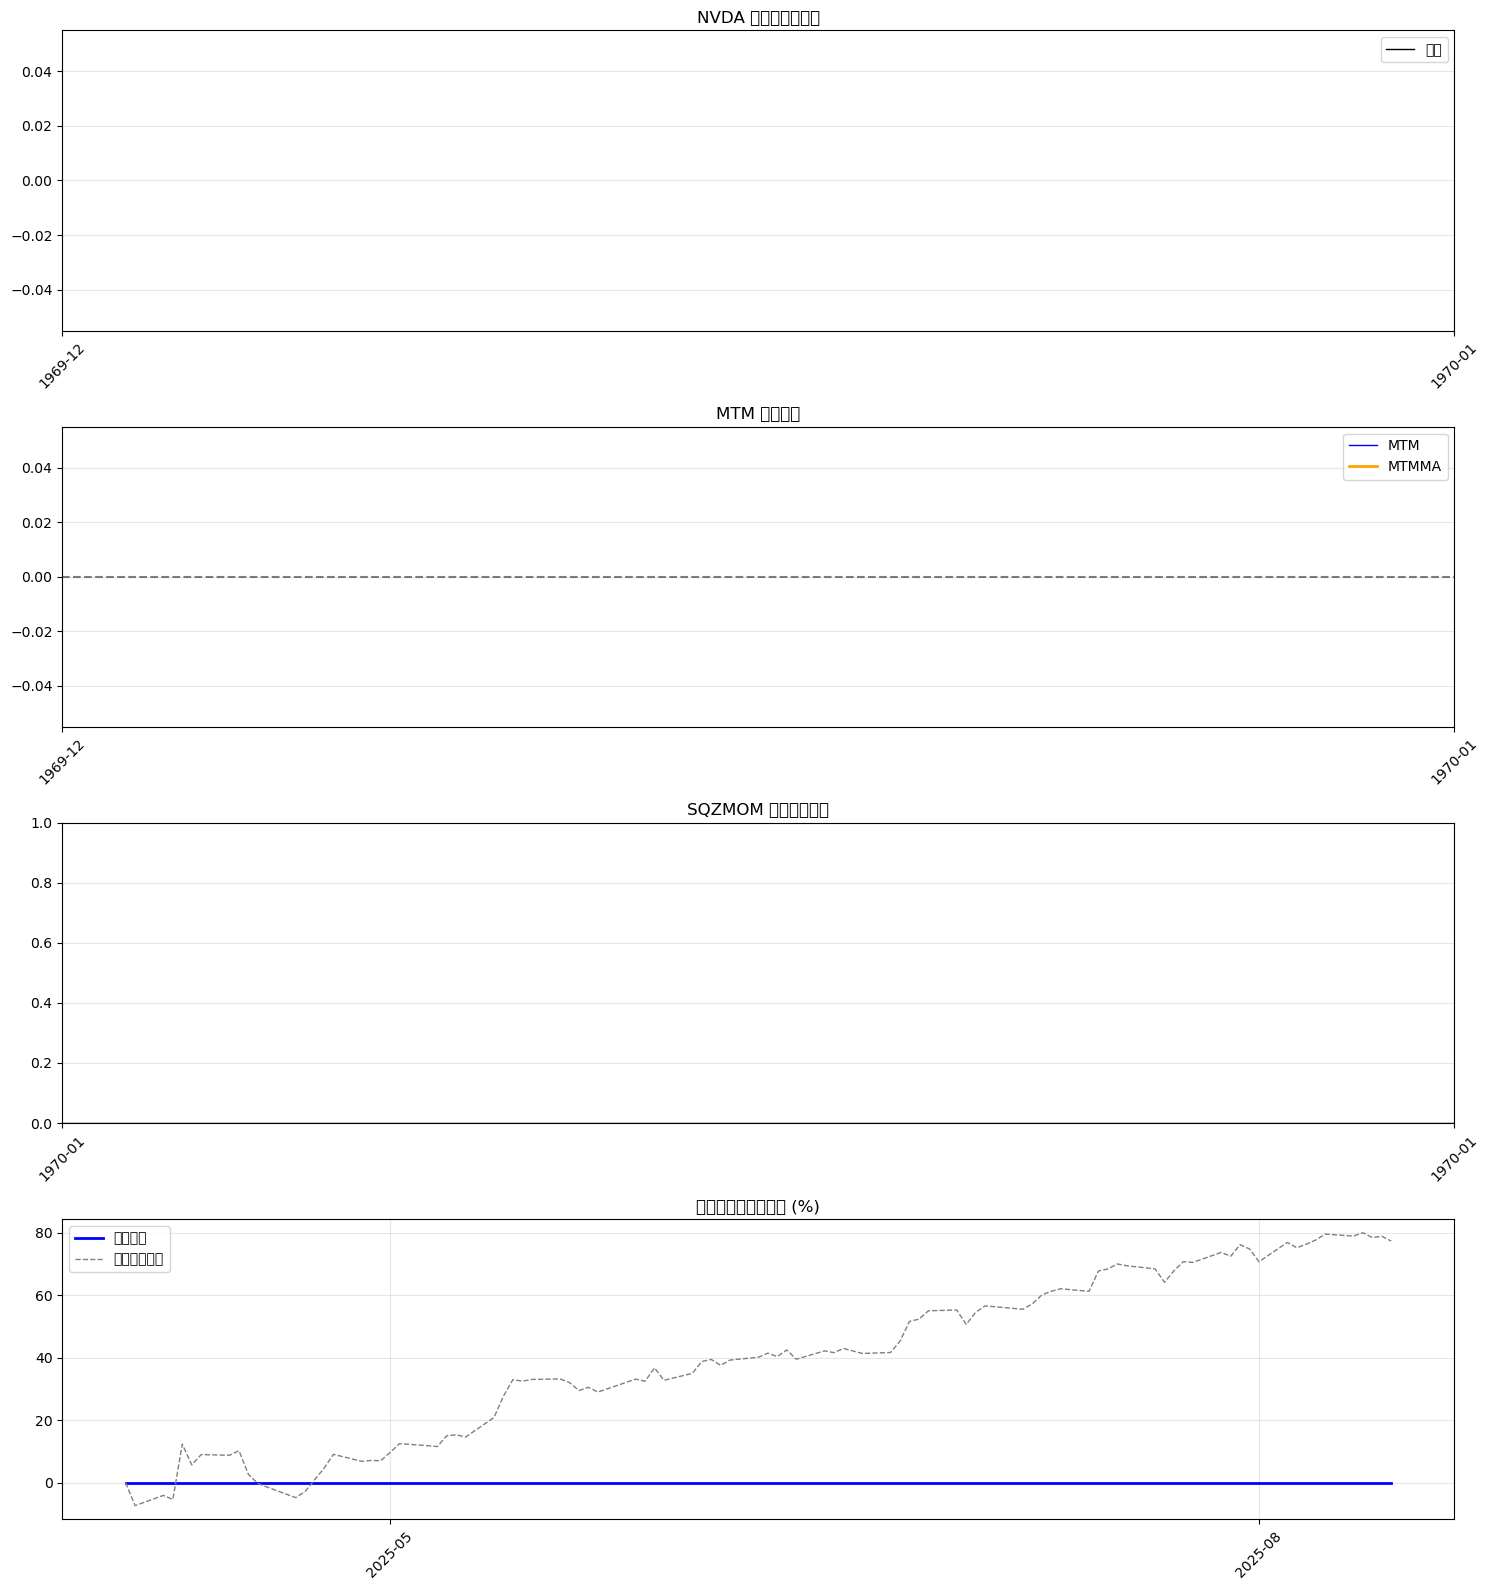

In [26]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class MTM_SQZMOM_Strategy:
    def __init__(self, initial_capital=100000):
        self.initial_capital = initial_capital
        
    def calculate_mtm(self, df, n=60, n1=40):
        """計算MTM指標"""
        df['MTM'] = df['Close'] - df['Close'].shift(n)
        df['MTMMA'] = df['MTM'].rolling(window=n1).mean()
        
        # MTM顏色邏輯
        df['MTM_Color'] = 'black'
        df.loc[df['MTM'] < df['MTMMA'], 'MTM_Color'] = 'red'
        df.loc[df['MTM'] > df['MTMMA'], 'MTM_Color'] = 'green'
        
        return df
    
    def calculate_sqzmom(self, df, bb_length=20, bb_mult=2.0, kc_length=20, kc_mult=1.5, use_true_range=True):
        """計算SQZMOM指標"""
        # 計算Bollinger Bands
        bb_basis = df['Close'].rolling(window=bb_length).mean()
        bb_dev = kc_mult * df['Close'].rolling(window=bb_length).std()
        upper_bb = bb_basis + bb_dev
        lower_bb = bb_basis - bb_dev
        
        # 計算Keltner Channel
        kc_ma = df['Close'].rolling(window=kc_length).mean()
        
        if use_true_range:
            high_low = df['High'] - df['Low']
            high_close_prev = np.abs(df['High'] - df['Close'].shift(1))
            low_close_prev = np.abs(df['Low'] - df['Close'].shift(1))
            true_range_df = pd.DataFrame({
                'hl': high_low,
                'hcp': high_close_prev,
                'lcp': low_close_prev
            }, index=df.index)
            true_range = true_range_df.max(axis=1)
        else:
            true_range = df['High'] - df['Low']
            
        range_ma = true_range.rolling(window=kc_length).mean()
        upper_kc = kc_ma + range_ma * kc_mult
        lower_kc = kc_ma - range_ma * kc_mult
        
        # Squeeze條件
        sqz_on = (lower_bb > lower_kc) & (upper_bb < upper_kc)
        sqz_off = (lower_bb < lower_kc) & (upper_bb > upper_kc)
        no_sqz = ~sqz_on & ~sqz_off
        
        # 計算momentum值
        highest_high = df['High'].rolling(window=kc_length).max()
        lowest_low = df['Low'].rolling(window=kc_length).min()
        avg_hl = (highest_high + lowest_low) / 2
        avg_close = df['Close'].rolling(window=kc_length).mean()
        avg_val = (avg_hl + avg_close) / 2
        
        # 線性回歸計算 - 簡化版本
        momentum_vals = []
        
        for i in range(len(df)):
            if i < kc_length - 1:
                momentum_vals.append(np.nan)
                continue
            
            try:
                # 獲取數據範圍
                start_idx = max(0, i - kc_length + 1)
                end_idx = i + 1
                
                # 計算基準值
                if pd.isna(avg_val.iloc[i]):
                    momentum_vals.append(np.nan)
                    continue
                    
                # 獲取價格數據並計算差值
                price_data = df['Close'].iloc[start_idx:end_idx].values
                base_value = avg_val.iloc[i]
                
                if len(price_data) < 2:
                    momentum_vals.append(np.nan)
                    continue
                
                # 計算相對於基準值的差
                y_data = price_data - base_value
                x_data = np.arange(len(y_data))
                
                # 檢查數據有效性
                if not np.any(np.isnan(y_data)) and len(y_data) > 1:
                    # 線性回歸計算斜率
                    slope, _ = np.polyfit(x_data, y_data, 1)
                    momentum_vals.append(slope * 100)  # 放大以便觀察
                else:
                    momentum_vals.append(np.nan)
                    
            except Exception as e:
                momentum_vals.append(np.nan)
        
        df['SQZMOM_Val'] = momentum_vals
        
        # SQZMOM顏色邏輯
        df['SQZMOM_Color'] = 'maroon'
        
        # 先處理基本的正負值
        positive_mask = df['SQZMOM_Val'] > 0
        negative_mask = df['SQZMOM_Val'] < 0
        
        # 計算前一個值
        prev_val = df['SQZMOM_Val'].shift(1)
        
        # 設定顏色
        df.loc[positive_mask & (df['SQZMOM_Val'] > prev_val), 'SQZMOM_Color'] = 'lime'
        df.loc[positive_mask & (df['SQZMOM_Val'] <= prev_val), 'SQZMOM_Color'] = 'green'
        df.loc[negative_mask & (df['SQZMOM_Val'] < prev_val), 'SQZMOM_Color'] = 'red'
        df.loc[negative_mask & (df['SQZMOM_Val'] >= prev_val), 'SQZMOM_Color'] = 'maroon'
        
        return df
    
    def backtest_strategy(self, symbol, start_date, end_date):
        """執行回測策略"""
        # 下載數據
        print(f"正在下載 {symbol} 的數據...")
        df = yf.download(symbol, start=start_date, end=end_date)
        
        if df.empty:
            raise ValueError(f"無法獲取 {symbol} 的數據")
        
        # 處理多層索引問題（如果存在）
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.droplevel(1)
        
        # 確保列名正確
        expected_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
        for col in expected_columns:
            if col not in df.columns:
                available_cols = [c for c in df.columns if col.lower() in c.lower()]
                if available_cols:
                    df[col] = df[available_cols[0]]
        
        # 計算指標
        df = self.calculate_mtm(df)
        df = self.calculate_sqzmom(df)
        
        # 交易信號
        # 買入條件: SQZMOM變綠 且 MTM變綠
        buy_condition = (df['SQZMOM_Color'].isin(['lime', 'green'])) & (df['MTM_Color'] == 'green')
        
        # 賣出條件: MTM變紅
        sell_condition = df['MTM_Color'] == 'red'
        
        # 初始化交易記錄
        df['Signal'] = 0
        df['Position'] = 0
        df['Portfolio_Value'] = self.initial_capital
        
        position = 0
        shares = 0
        cash = self.initial_capital
        trades_log = []
        
        for i in range(1, len(df)):
            current_price = df['Close'].iloc[i]
            current_date = df.index[i]
            
            # 買入信號
            if buy_condition.iloc[i] and position == 0:
                shares = cash / current_price
                cash = 0
                position = 1
                df.loc[current_date, 'Signal'] = 1
                trades_log.append(f"買入: {current_date.strftime('%Y-%m-%d')} 價格: ${current_price:.2f}")
                
            # 賣出信號
            elif sell_condition.iloc[i] and position == 1:
                cash = shares * current_price
                shares = 0
                position = 0
                df.loc[current_date, 'Signal'] = -1
                trades_log.append(f"賣出: {current_date.strftime('%Y-%m-%d')} 價格: ${current_price:.2f}")
            
            # 更新投資組合價值
            portfolio_value = cash + (shares * current_price if shares > 0 else 0)
            df.loc[current_date, 'Portfolio_Value'] = portfolio_value
            df.loc[current_date, 'Position'] = position
        
        # 計算收益率
        df['Returns'] = df['Portfolio_Value'].pct_change()
        df['Cumulative_Returns'] = (df['Portfolio_Value'] / self.initial_capital) - 1
        
        # 計算基準收益（買入並持有） - 修正版
        # 假設在第一個交易日用所有資金買入股票並持有
        first_price = df['Close'].iloc[0]
        shares_buy_hold = self.initial_capital / first_price
        df['Buy_Hold_Value'] = shares_buy_hold * df['Close']
        df['Buy_Hold_Cumulative'] = (df['Buy_Hold_Value'] / self.initial_capital) - 1
        
        # 保存交易記錄
        self.trades_log = trades_log
        
        return df
    
    def calculate_sharpe_ratio(self, df, risk_free_rate=0.02):
        """計算夏普比率"""
        returns = df['Returns'].dropna()
        excess_returns = returns - risk_free_rate / 252
        if excess_returns.std() == 0:
            return 0
        return np.sqrt(252) * excess_returns.mean() / excess_returns.std()
    
    def plot_results(self, df, symbol):
        """繪製結果圖表"""
        fig, axes = plt.subplots(4, 1, figsize=(15, 16))
        
        # 移除NaN值用於繪圖
        plot_df = df.dropna(subset=['MTM', 'MTMMA', 'SQZMOM_Val'])
        
        # 價格圖表
        axes[0].plot(plot_df.index, plot_df['Close'], label='股價', color='black', linewidth=1)
        
        # 標記買賣點
        buy_signals = plot_df[plot_df['Signal'] == 1]
        sell_signals = plot_df[plot_df['Signal'] == -1]
        
        if len(buy_signals) > 0:
            axes[0].scatter(buy_signals.index, buy_signals['Close'], 
                           color='green', marker='^', s=100, label='買入', zorder=5)
        if len(sell_signals) > 0:
            axes[0].scatter(sell_signals.index, sell_signals['Close'], 
                           color='red', marker='v', s=100, label='賣出', zorder=5)
        
        axes[0].set_title(f'{symbol} 價格與交易信號')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # MTM指標
        axes[1].plot(plot_df.index, plot_df['MTM'], label='MTM', color='blue', linewidth=1)
        axes[1].plot(plot_df.index, plot_df['MTMMA'], label='MTMMA', color='orange', linewidth=2)
        axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[1].set_title('MTM 動量指標')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # SQZMOM指標
        sqz_df = plot_df.dropna(subset=['SQZMOM_Val'])
        if len(sqz_df) > 0:
            colors = []
            for color in sqz_df['SQZMOM_Color']:
                if color == 'lime':
                    colors.append('lime')
                elif color == 'green':
                    colors.append('green')
                elif color == 'red':
                    colors.append('red')
                else:
                    colors.append('maroon')
            
            # 計算合適的柱寬
            if len(sqz_df) > 1:
                time_diff = (sqz_df.index[-1] - sqz_df.index[0]).days
                bar_width = max(1, time_diff / len(sqz_df) * 0.8)
            else:
                bar_width = 1
                
            axes[2].bar(sqz_df.index, sqz_df['SQZMOM_Val'], 
                       color=colors, alpha=0.7, width=bar_width)
            
        axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axes[2].set_title('SQZMOM 擠壓動量指標')
        axes[2].grid(True, alpha=0.3)
        
        # 投資組合表現
        perf_df = df.dropna(subset=['Cumulative_Returns', 'Buy_Hold_Cumulative'])
        axes[3].plot(perf_df.index, perf_df['Cumulative_Returns'] * 100, 
                    label='策略收益', color='blue', linewidth=2)
        axes[3].plot(perf_df.index, perf_df['Buy_Hold_Cumulative'] * 100, 
                    label='買入持有收益', color='gray', linewidth=1, linestyle='--')
        axes[3].set_title('投資組合累計收益率 (%)')
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)
        
        # 格式化x軸
        for ax in axes:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    def run_strategy(self, symbol, start_date, end_date, plot=True):
        """運行完整策略"""
        print("=== MTM-SQZMOM 交易策略回測 ===")
        print(f"股票代號: {symbol}")
        print(f"回測期間: {start_date} 至 {end_date}")
        print(f"初始資金: ${self.initial_capital:,}")
        print("-" * 50)
        
        # 執行回測
        df = self.backtest_strategy(symbol, start_date, end_date)
        
        # 計算績效指標
        final_value = df['Portfolio_Value'].iloc[-1]
        total_return = (final_value - self.initial_capital) / self.initial_capital
        
        # 修正的買入持有收益計算
        buy_hold_final_value = df['Buy_Hold_Value'].iloc[-1]
        buy_hold_return = (buy_hold_final_value - self.initial_capital) / self.initial_capital
        
        sharpe_ratio = self.calculate_sharpe_ratio(df)
        
        # 計算最大回撤
        rolling_max = df['Portfolio_Value'].expanding().max()
        drawdown = (df['Portfolio_Value'] - rolling_max) / rolling_max
        max_drawdown = drawdown.min()
        
        # 交易次數
        trades = len(df[df['Signal'] != 0])
        
        # 打印交易記錄
        if hasattr(self, 'trades_log') and len(self.trades_log) > 0:
            print("\n交易記錄:")
            for trade in self.trades_log[-10:]:  # 只顯示最後10筆交易
                print(trade)
            if len(self.trades_log) > 10:
                print(f"... 共 {len(self.trades_log)} 筆交易")
        
        # 打印結果
        # 打印結果
        print(f"最終投資組合價值: ${final_value:,.2f}")
        print(f"買入持有最終價值: ${buy_hold_final_value:,.2f}")
        print(f"策略總收益率: {total_return*100:.2f}%")
        print(f"買入持有收益率: {buy_hold_return*100:.2f}%")
        print(f"超額收益: {(total_return - buy_hold_return)*100:.2f}%")
        print(f"夏普比率: {sharpe_ratio:.2f}")
        print(f"最大回撤: {max_drawdown*100:.2f}%")
        print(f"交易次數: {trades}")
        
        if plot:
            self.plot_results(df, symbol)
        
        return df

# 使用示例
if __name__ == "__main__":
    # 創建策略實例
    strategy = MTM_SQZMOM_Strategy(initial_capital=100000)
    
    # 運行策略 - 以蘋果公司為例
    try:
        results = strategy.run_strategy(
            symbol="NVDA",           # 股票代號
            start_date="2025-04-03", # 開始日期
            end_date="2025-08-31",   # 結束日期
            plot=True                # 是否繪圖
        )
    except Exception as e:
        print(f"錯誤: {e}")
        
    # 您可以修改以下參數來測試不同的股票和時間範圍:
    # symbol: 股票代號 (如 "TSLA", "MSFT", "GOOGL" 等)
    # start_date: 開始日期 (格式: "YYYY-MM-DD")
    # end_date: 結束日期 (格式: "YYYY-MM-DD")
    # initial_capital: 初始資金